In [2]:
import copy
import time
import gc
import ray
import os
import shutil
import numpy as np
import pandas as pd
from graphillion import setset, GraphSet
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from mfd_dynamics import MFD_Dynamics
from parameters_ndp import Parameters
from reconf_horizon import ReconfigZDD

params = Parameters()
num_zones = params.num_zones
link_indices = [(i, j) for i in range(num_zones) for j in range(num_zones) if params.adj_matrix[i, j] == 1]

reconf_start_time = 6 * 60
reconf_end_time = 12 * 60
seq_interval = 60 # min. 遷移のステップ幅
time_steps = int((reconf_end_time - reconf_start_time) // seq_interval)
initial_graph = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
#target_graph =  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0] # 93max_1.0
#target_graph = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0] # 93max_0.9
target_graph = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0] # 93max_0.8
#target_graph =  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0] # 53_0.95_1.0


output_path = "/Users/masudasatoki/Desktop/MFD_evac/code/reconfigration/output/mfd_dynamics/green_0.5/demand_36h/93_max/back0.8"

reconf = ReconfigZDD(params, initial_graph, target_graph, k=time_steps, constraints_csv=None, output_path=output_path+"/0_24_control6_evac/reconf")
reconf_seq = pd.read_csv(output_path+"/0_24_control6_evac/best_sequence.csv", header=None).values.tolist()
reconf_seq_graph =[[(f"{i}_out", f"{j}_in") for idx, (i, j) in enumerate(link_indices) if reconf_seq[step][idx] == 1] for step in range(len(reconf_seq)) ]
reconf.draw_sequence(reconf_seq_graph)

reconf = ReconfigZDD(params, initial_graph, target_graph, k=time_steps, constraints_csv=None, output_path=output_path+"/0_24_control6_normal/reconf")
reconf_seq = pd.read_csv(output_path+"/0_24_control6_normal/best_sequence.csv", header=None).values.tolist()
reconf_seq_graph =[[(f"{i}_out", f"{j}_in") for idx, (i, j) in enumerate(link_indices) if reconf_seq[step][idx] == 1] for step in range(len(reconf_seq)) ]
reconf.draw_sequence(reconf_seq_graph)

Number of edges in the original SUMO graph: 12799
Number of nodes in the networkx graph: 5528
Number of edges in the networkx graph: 12674
Created graphs successfully


In [1]:
import random
from collections import deque
import math
from tqdm import tqdm

def build_layered_dag(level_sizes, out_degree):
    """
    レベル付き DAG を生成する。

    level_sizes: 各レベルの頂点数のリスト [n0, n1, ..., nL-1]
    out_degree:  最終レベル以外の各頂点の出次数（固定）

    レベル l の頂点集合は，連番 ID の区間 [offset[l], offset[l+1]) に対応。
    辺は常に level l → level l+1 にだけ張るので DAG になる。
    """
    assert len(level_sizes) >= 2, "レベル数は少なくとも 2"
    num_levels = len(level_sizes)

    # 各レベルの開始インデックスを作る
    offset = [0] * (num_levels + 1)
    for i in range(num_levels):
        offset[i + 1] = offset[i] + level_sizes[i]

    n = offset[-1]  # 全頂点数
    adj = [[] for _ in range(n)]


    for lvl in range(num_levels - 1):
        curr_begin = offset[lvl]
        curr_end   = offset[lvl + 1]
        next_begin = offset[lvl + 1]
        next_end   = offset[lvl + 2]

        curr_nodes = range(curr_begin, curr_end)
        next_nodes = list(range(next_begin, next_end))

        # 固定出次数 out_degree を満たすには、次レベルの頂点数が十分必要
        if out_degree > len(next_nodes):
            raise ValueError(
                f"レベル {lvl} → {lvl+1} の遷移で "
                f"out_degree={out_degree} に対して次レベルの頂点数が不足しています: {len(next_nodes)}"
            )

        for u in curr_nodes:
            # 次レベルから out_degree 個の異なる頂点を選ぶ
            adj[u] = random.sample(next_nodes, out_degree)

    # 始点: レベル0の先頭
    s = offset[0]  # = 0
    # 終点: 最終レベルからランダムに選ぶ
    t = random.randint(offset[num_levels - 1], offset[num_levels]-1)

    return adj, s, t, offset


def count_num_shortest_paths(adj, s, t):
    """
    有向グラフ adj 上で，
    s -> t の最短距離とその本数を求める（辺重みはすべて 1）。
    到達不能なときは (None, 0) を返す。
    """
    n = len(adj)
    INF = 10**18
    dist = [INF] * n
    ways = [0] * n

    dist[s] = 0
    ways[s] = 1

    q = deque([s])
    while q:
        u = q.popleft()
        for v in adj[u]:
            # 初めて到達
            if dist[v] == INF:
                dist[v] = dist[u] + 1
                ways[v] = ways[u]
                q.append(v)
            # 同じ長さの別の最短経路が見つかった
            elif dist[v] == dist[u] + 1:
                ways[v] += ways[u]

    if dist[t] == INF:
        return None, 0
    return dist[t], ways[t]

def combination(n, r):
    return math.factorial(n) // (math.factorial(r) * math.factorial(n - r))

if __name__ == "__main__":
    # 例:
    r = 15
    level_sizes = [1, 
                   1+r, 
                   1+r+combination(r, 2), 
                   1+r+combination(r, 2)+combination(r, 3), 
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4), 
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5),
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6),
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6)+combination(r, 7)]
                   #1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6)+combination(r, 7)+combination(r, 8)] 
    out_degree = r  # 各頂点の出次数（最終レベル以外）

    num_path_list = []
    all_path_list = []
    efficiency_list = []
    for _ in tqdm(range(10)):
        adj, s, t, offset = build_layered_dag(level_sizes, out_degree)

        dist, num_paths = count_num_shortest_paths(adj, s, t)

        num_path_list.append(num_paths)
        all_path_list.append(r**(len(level_sizes)-2))
        efficiency_list.append(num_paths / r**(len(level_sizes)-2) * 100)
        #print(f"num_nodes = {len(adj)}")
        #print(f"start = {s} (level 0), goal = {t} (last level)")
        #print("shortest distance:", dist)
        #print("number of shortest paths:", num_paths)
        #print("number of all paths:", r**(len(level_sizes)-2))
        #print("Sampling efficiency:", num_paths / r**(len(level_sizes)-2) * 100, "%")

    print("Average number of shortest paths:", sum(num_path_list)/len(num_path_list))
    print("Average number of all paths:", sum(all_path_list)/len(all_path_list))
    print("Average sampling efficiency:", sum(efficiency_list)/len(efficiency_list), "%")
    # 必要なら隣接リストを確認
    # for u, nbrs in enumerate(adj):
    #     print(u, "->", nbrs)

100%|██████████| 10/10 [00:01<00:00,  9.47it/s]

Average number of shortest paths: 11322.1
Average number of all paths: 11390625.0
Average sampling efficiency: 0.09939840877914953 %


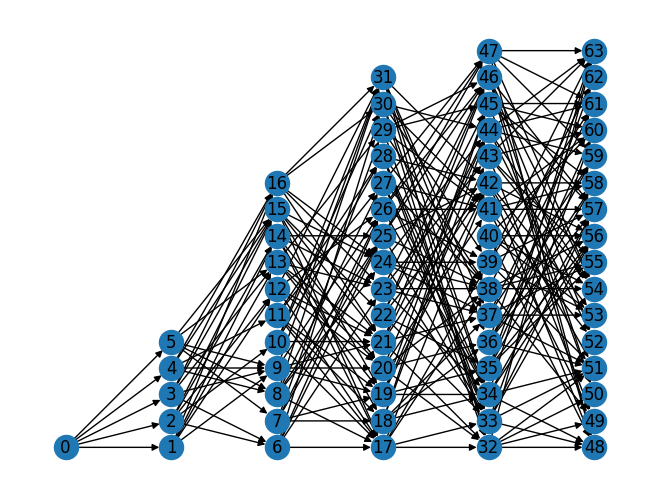

In [3]:
# networkxで可視化
import networkx as nx
from matplotlib import pyplot as plt
G = nx.DiGraph()
for u, nbrs in enumerate(adj):
    for v in nbrs:
        G.add_edge(u, v)
# posをoffsetに従って設定
pos = {}
node_id = 0
for level_idx, num_nodes_in_level in enumerate(level_sizes):
    for node_in_level in range(num_nodes_in_level):
        pos[node_id] = (level_idx, node_in_level)
        node_id += 1

nx.draw(G, pos=pos, with_labels=True)
plt.show()

In [ ]:
import random
from collections import deque
import math
from tqdm import tqdm

def build_layered_dag(level_sizes, out_degree):
    """
    レベル付き DAG を生成する。

    level_sizes: 各レベルの頂点数のリスト [n0, n1, ..., nL-1]
    out_degree:  最終レベル以外の各頂点の出次数（固定）

    レベル l の頂点集合は，連番 ID の区間 [offset[l], offset[l+1]) に対応。
    辺は常に level l → level l+1 にだけ張るので DAG になる。
    """
    assert len(level_sizes) >= 2, "レベル数は少なくとも 2"
    num_levels = len(level_sizes)

    # 各レベルの開始インデックスを作る
    offset = [0] * (num_levels + 1)
    for i in range(num_levels):
        offset[i + 1] = offset[i] + level_sizes[i]

    n = offset[-1]  # 全頂点数
    adj = [[] for _ in range(n)]


    for lvl in range(num_levels - 1):
        curr_begin = offset[lvl]
        curr_end   = offset[lvl + 1]
        next_begin = offset[lvl + 1]
        next_end   = offset[lvl + 2]

        curr_nodes = range(curr_begin, curr_end)
        next_nodes = list(range(next_begin, next_end))

        # 固定出次数 out_degree を満たすには、次レベルの頂点数が十分必要
        if out_degree > len(next_nodes):
            raise ValueError(
                f"レベル {lvl} → {lvl+1} の遷移で "
                f"out_degree={out_degree} に対して次レベルの頂点数が不足しています: {len(next_nodes)}"
            )

        for u in curr_nodes:
            # 次レベルから out_degree 個の異なる頂点を選ぶ
            adj[u] = random.sample(next_nodes, out_degree)

    # 始点: レベル0の先頭
    s = offset[0]  # = 0
    # 終点: 最終レベルからランダムに選ぶ
    t = random.randint(offset[num_levels - 1], offset[num_levels]-1)

    return adj, s, t, offset


def count_num_shortest_paths(adj, s):
    """
    有向グラフ adj 上で，
    s -> 最終levelまで の最短距離とその本数を求める（辺重みはすべて 1）。
    到達不能なときは (None, 0) を返す。
    """
    n = len(adj)
    INF = 10**18
    dist = [INF] * n
    ways = [0] * n

    dist[s] = 0
    ways[s] = 1

    q = deque([s])
    while q:
        u = q.popleft()
        for v in adj[u]:
            # 初めて到達
            if dist[v] == INF:
                dist[v] = dist[u] + 1
                ways[v] = ways[u]
                q.append(v)
            # 同じ長さの別の最短経路が見つかった
            elif dist[v] == dist[u] + 1:
                ways[v] += ways[u]

    if dist[t] == INF:
        return None, 0
    return dist[t], ways[t]

def combination(n, r):
    return math.factorial(n) // (math.factorial(r) * math.factorial(n - r))

if __name__ == "__main__":
    # 例:
    r = 15
    level_sizes = [1, 
                   1+r, 
                   1+r+combination(r, 2), 
                   1+r+combination(r, 2)+combination(r, 3), 
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4), 
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5),
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6),
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6)+combination(r, 7)]
                   #1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6)+combination(r, 7)+combination(r, 8)] 
    out_degree = r  # 各頂点の出次数（最終レベル以外）

    num_path_list = []
    all_path_list = []
    efficiency_list = []
    for _ in tqdm(range(10)):
        adj, s, t, offset = build_layered_dag(level_sizes, out_degree)

        dist, num_paths = count_num_shortest_paths(adj, s, t)

        num_path_list.append(num_paths)
        all_path_list.append(r**(len(level_sizes)-2))
        efficiency_list.append(num_paths / r**(len(level_sizes)-2) * 100)
        #print(f"num_nodes = {len(adj)}")
        #print(f"start = {s} (level 0), goal = {t} (last level)")
        #print("shortest distance:", dist)
        #print("number of shortest paths:", num_paths)
        #print("number of all paths:", r**(len(level_sizes)-2))
        #print("Sampling efficiency:", num_paths / r**(len(level_sizes)-2) * 100, "%")

    print("Average number of shortest paths:", sum(num_path_list)/len(num_path_list))
    print("Average number of all paths:", sum(all_path_list)/len(all_path_list))
    print("Average sampling efficiency:", sum(efficiency_list)/len(efficiency_list), "%")
    # 必要なら隣接リストを確認
    # for u, nbrs in enumerate(adj):
    #     print(u, "->", nbrs)

In [ ]:
# networkxで可視化
import networkx as nx
from matplotlib import pyplot as plt
G = nx.DiGraph()
for u, nbrs in enumerate(adj):
    for v in nbrs:
        G.add_edge(u, v)
# posをoffsetに従って設定
pos = {}
node_id = 0
for level_idx, num_nodes_in_level in enumerate(level_sizes):
    for node_in_level in range(num_nodes_in_level):
        pos[node_id] = (level_idx, node_in_level)
        node_id += 1

nx.draw(G, pos=pos, with_labels=True)
plt.show()